In [ ]:
# Question of interest: what is a good spectrum? 

# Dataset used: Fanzhou's serial dilution data, where high conc. spectrums serve as ground truth
# Goal: Use useful features to annotate each spectrum with a "goodness" score

In [1]:
import os
os.chdir("/Users/ellayoung/Desktop/metabolo_confi_score")

In [2]:
import sys
import os

# Add the root project directory to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("/Users/ellayoung/Desktop/metabolo_confi_score"), "..")))


In [3]:
# from MegaMoNA import *
# 

In [4]:
# dilution data from Fanzhou
import pandas as pd
df = pd.read_csv("/Users/ellayoung/Desktop/metabolo_confi_score/data/dilution_data_all.csv")
df = df[df["spectral_entropy"] >= 0]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11267 entries, 0 to 11822
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    11267 non-null  object 
 1   mix                     11267 non-null  int64  
 2   conc                    11267 non-null  int64  
 3   ce                      11267 non-null  int64  
 4   mono_mass               11267 non-null  float64
 5   rt                      11267 non-null  float64
 6   smiles                  11267 non-null  object 
 7   formula                 11267 non-null  object 
 8   adduct                  11267 non-null  object 
 9   reference_precursor_mz  11267 non-null  float64
 10  rt (min)                11267 non-null  float64
 11  precursor_mz            11267 non-null  float64
 12  height                  11267 non-null  float64
 13  ms1                     11267 non-null  object 
 14  peaks                   11267 non-null  obj

In [6]:
print(df.head())

                                             name  mix  conc  ce   mono_mass  \
0                                      Hesperidin    6     6  65  610.189770   
1                   4-Hydroxy-6-Methylpyran-2-One    6     6  65  126.031694   
2                                  Acetosyringone    6     6  65  196.073559   
3  3,4-Didesmethyl-5-Deshydroxy-3'-Ethoxyscleroin    6     6  65  274.084124   
4                                Piperonylic Acid    6     6  65  166.026609   

     rt                                             smiles    formula  adduct  \
0  5.77  COc1ccc(C2CC(=O)c3c(O)cc(OC4OC(COC5OC(C)C(O)C(...  C28H34O15  [M+H]+   
1  3.61                                   Cc1cc(O)cc(=O)o1     C6H6O3  [M+H]+   
2  5.42                            COc1cc(C(C)=O)cc(OC)c1O   C10H12O4  [M+H]+   
3  8.49                  CCOc1cccc(C(=O)c2ccc(O)c(O)c2O)c1   C15H14O5  [M+H]+   
4  5.87                              O=C(O)c1ccc2c(c1)OCO2     C8H6O4  [M+H]+   

   reference_precursor_mz  ...  

<Axes: xlabel='spectral_entropy', ylabel='Count'>

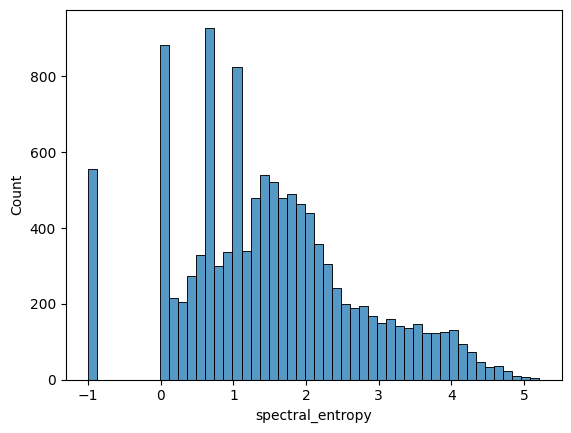

In [9]:
import seaborn as sns
sns.histplot(df["spectral_entropy"], bins=50)

<Axes: xlabel='conc', ylabel='Count'>

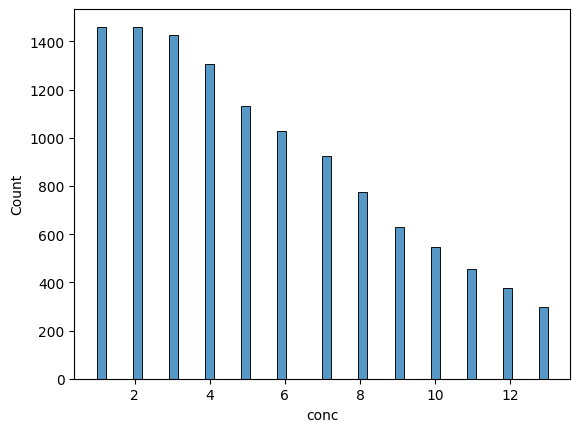

In [10]:
sns.histplot(df["conc"], bins=50)

<Axes: xlabel='height', ylabel='spectral_entropy'>

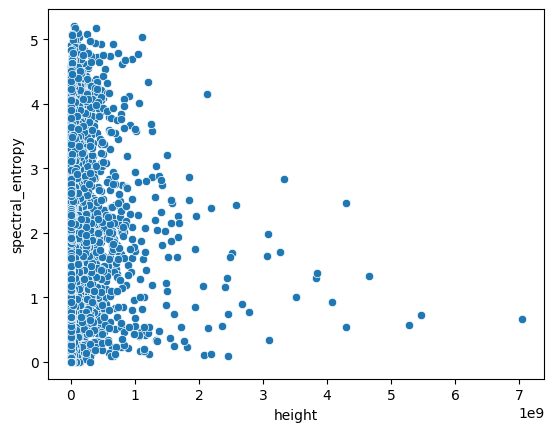

In [8]:
sns.scatterplot(x="height", y="spectral_entropy", data=df)


<Axes: xlabel='ei', ylabel='spectral_entropy'>

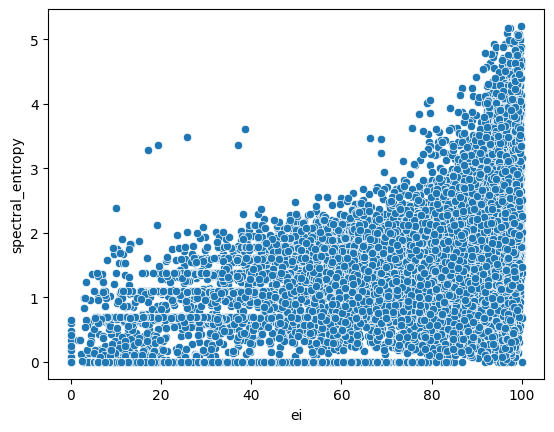

In [9]:
sns.scatterplot(x="ei", y="spectral_entropy", data=df)

In [7]:
# Re-import necessary elements since session reset
import pandas as pd
import numpy as np
from scipy.stats import skew

# Load the dataset from the user's earlier shared CSV path
df = pd.read_csv("/Users/ellayoung/Desktop/metabolo_confi_score/data/dilution_data_all.csv")

# Redefine utility functions
def parse_peak_string(peak_str):
    try:
        peaks = [list(map(float, p.split('\t'))) for p in peak_str.strip().split('\n')]
        peaks = np.array(peaks)
        mz = peaks[:, 0]
        intensity = peaks[:, 1]
        return mz, intensity
    except:
        return None, None

def compute_spectrum_features(peak_str):
    mz, intensity = parse_peak_string(peak_str)
    if mz is None or len(mz) == 0:
        return pd.Series([np.nan] * 5, index=["num_peaks", "base_peak_fraction", "top3_fraction", "intensity_skew", "mz_range"])
    
    total_intensity = np.sum(intensity)
    base_peak_fraction = np.max(intensity) / total_intensity if total_intensity > 0 else np.nan
    top3_fraction = np.sum(np.sort(intensity)[-3:]) / total_intensity if total_intensity > 0 else np.nan
    intensity_skew = skew(intensity) if len(intensity) > 2 else np.nan
    mz_range = np.max(mz) - np.min(mz) if len(mz) > 1 else 0.0
    return pd.Series([len(mz), base_peak_fraction, top3_fraction, intensity_skew, mz_range],
                     index=["num_peaks", "base_peak_fraction", "top3_fraction", "intensity_skew", "mz_range"])

# Apply the feature extractor
spectrum_features = df["peaks"].apply(compute_spectrum_features)
df = pd.concat([df, spectrum_features], axis=1)
# Replace this:
# import ace_tools as tools; tools.display_dataframe_to_user(...)

# With this:
print(df[[
    "name", "conc", "ei", "spectral_entropy", "num_peaks", 
    "base_peak_fraction", "top3_fraction", "intensity_skew", "mz_range"
]].head(10))  # or use .to_csv(), .describe(), etc.


                                             name  conc         ei  \
0                                      Hesperidin     6  94.396715   
1                   4-Hydroxy-6-Methylpyran-2-One     6  91.601405   
2                                  Acetosyringone     6  87.762371   
3  3,4-Didesmethyl-5-Deshydroxy-3'-Ethoxyscleroin     6  96.392759   
4                                Piperonylic Acid     6  51.237031   
5                           7,2'-Dihydroxyflavone     6  91.561132   
6                               4-Methyldaphnetin     6  97.343758   
7                                      Naringenin     6  98.066184   
8                       Catechin Tetramethylether     6  98.864009   
9                                      Hesperetin     6  99.071334   

   spectral_entropy  num_peaks  base_peak_fraction  top3_fraction  \
0          2.499081       22.0            0.164429       0.439491   
1          2.072710       18.0            0.308865       0.564558   
2          1.014745   

In [3]:
df["quality_score"] = (
    0.6 * df["ei"] -                  # reward chemically plausible
    40 * df["spectral_entropy"] +    # penalize high complexity
    20 * df["base_peak_fraction"] +  # reward sharp spectra
    15 * df["top3_fraction"]         # reward focused signal
)


<Axes: xlabel='quality_score', ylabel='Count'>

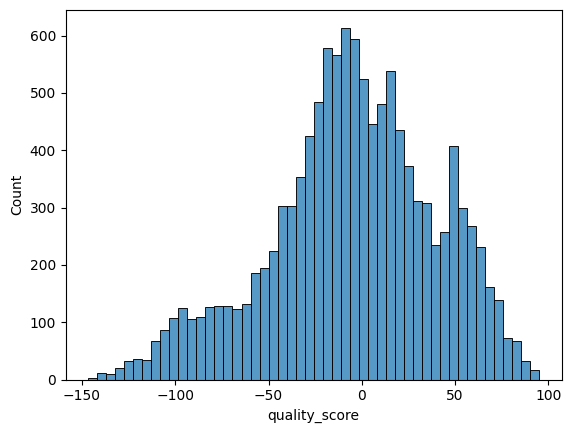

In [12]:
import seaborn as sns
sns.histplot(df["quality_score"], bins=50)


<Axes: xlabel='conc', ylabel='quality_score'>

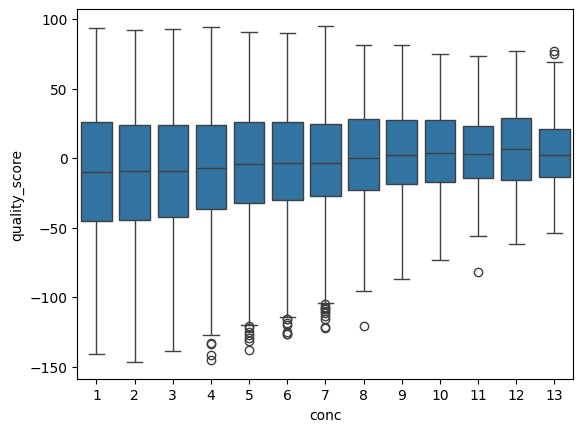

In [13]:
sns.boxplot(x="conc", y="quality_score", data=df)


In [14]:
df["is_ground_truth"] = df["conc"] == 13


<Axes: xlabel='is_ground_truth', ylabel='quality_score'>

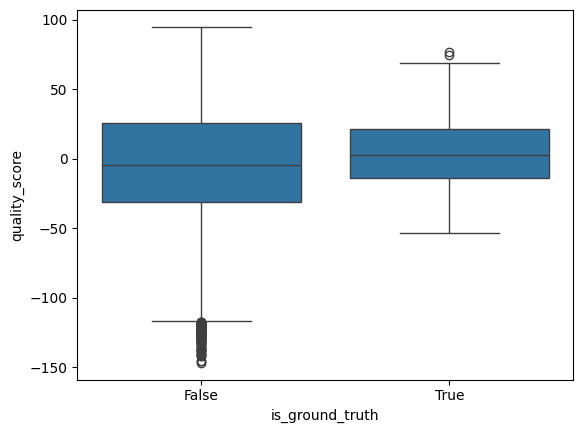

In [15]:
import seaborn as sns
sns.boxplot(x="is_ground_truth", y="quality_score", data=df)


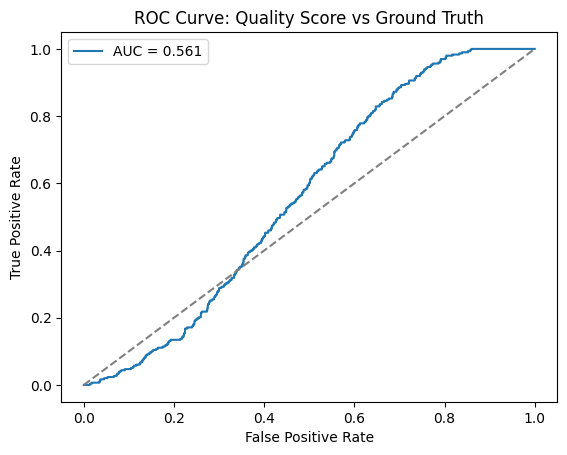

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_true = df["is_ground_truth"]
y_score = df["quality_score"]

fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Quality Score vs Ground Truth")
plt.legend()
plt.show()


In [17]:
from sklearn.linear_model import LogisticRegression

features = ["ei", "spectral_entropy", "base_peak_fraction", "top3_fraction"]
X = df[features]
y = df["is_ground_truth"]

model = LogisticRegression()
model.fit(X, y)
df["model_score"] = model.predict_proba(X)[:, 1]


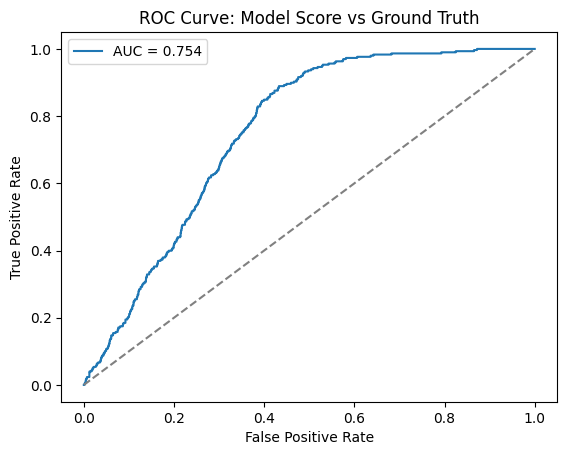

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_true = df["is_ground_truth"]
y_score = df["model_score"]

fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Model Score vs Ground Truth")
plt.legend()
plt.show()


In [19]:
for name, coef in zip(X.columns, model.coef_[0]):
    print(f"{name}: {coef:.2f}")


ei: -0.03
spectral_entropy: 0.09
base_peak_fraction: -0.45
top3_fraction: 0.70


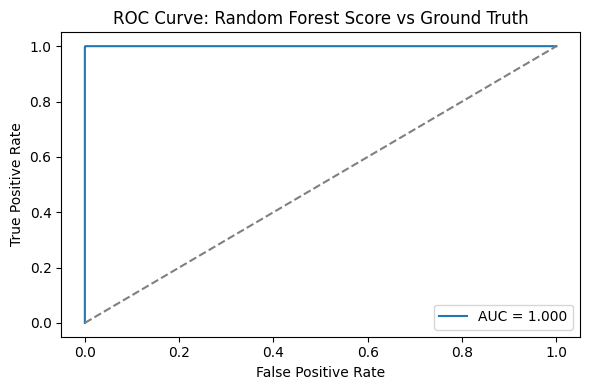

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Define features and labels
features = ["ei", "spectral_entropy", "base_peak_fraction", "top3_fraction"]
X = df[features]
y = df["conc"] == 13  # Ground truth label

# Train a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Generate predicted probabilities
df["rf_score"] = rf_model.predict_proba(X)[:, 1]

# Compute and plot ROC curve
fpr, tpr, _ = roc_curve(y, df["rf_score"])
auc = roc_auc_score(y, df["rf_score"])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Random Forest Score vs Ground Truth")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, rf_probs)


0.6999039301310044

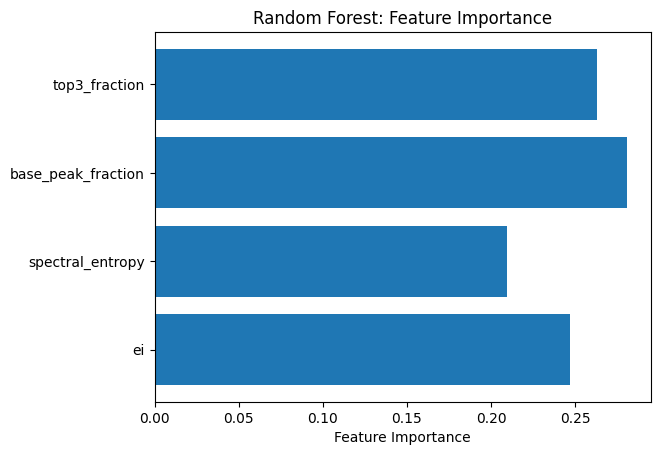

In [22]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest: Feature Importance")
plt.show()


In [23]:
# tuning the model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, 
                    scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X, y)
print("Best AUC:", grid.best_score_)
print("Best Params:", grid.best_params_)


Best AUC: 0.776108202507445
Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')
print("Mean AUC:", scores.mean())


Mean AUC: 0.6909478534750052


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Define features and label
features = ["ei", "spectral_entropy", "base_peak_fraction", "top3_fraction"]
X = df[features]
y = df["conc"] == 13

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost model
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_estimators=100,        # limit the number of trees
    max_depth=3,             # keep trees shallow
    learning_rate=0.1,       # normal learning rate
    subsample=0.8,           # use 80% of rows per tree (memory saving)
    colsample_bytree=0.8,    # use 80% of features per tree
    tree_method='hist',      # **VERY important** - much more memory-efficient
    n_jobs=2                 # limit number of threads to 2
)

xgb_model.fit(X_train, y_train)

# Predict probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC and AUC
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
auc = roc_auc_score(y_test, xgb_probs)

# Plot ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost vs Ground Truth")
plt.legend()
plt.tight_layout()
plt.show()
